In [39]:
import db_utils as db_utils
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [34]:
""" Creating a connection with the table: """

' Creating a connection with the table: '

In [35]:
conn = sqlite3.connect('employee.sqlite')
print("Opened database successfully")

# db_utils.create_db(conn)
# db_utils.populate_db(conn)

res = conn.execute('SELECT * FROM EMPLOYEE')
print(res.fetchall())

conn.close()

conn = sqlite3.connect('employee.sqlite')
print("Opened database successfully")


Opened database successfully
[('James', 'E', 'Borg', '888665555', '1937-11-10', '450 Stone, Houston, TX', 'M', 55000, None, 1), ('Franklin', 'T', 'Wong', '333445555', '1955-12-08', '638 Voss, Houston, TX', 'M', 40000, '888665555', 5), ('John', 'B', 'Smith', '123456789', '1965-01-09', '731 Fondren, Houston, TX', 'M', 30000, '333445555', 5), ('Jennifer', 'S', 'Wallace', '987654321', '1941-06-20', '291 Berry, Bellaire, TX', 'F', 43000, '888665555', 4), ('Alicia', 'J', 'Zelaya', '999887777', '1968-01-19', '3321 Castle, Spring, TX', 'F', 25000, '987654321', 4), ('Ramesh', 'K', 'Narayan', '666884444', '1962-09-15', '975 Fire Oak, Humble, TX', 'M', 38000, '333445555', 5), ('Joyce', 'A', 'English', '453453453', '1972-07-31', '5631 Rice, Houston, TX', 'F', 25000, '333445555', 5), ('Ahmad', 'V', 'Jabbar', '987987987', '1969-03-29', '980 Dallas, Houston, TX', 'M', 25000, '333445555', 5)]
Opened database successfully


## QUESTÃO 1

In [36]:
"""A primeira query retorna os nomes e sobrenomes dos funcionários que estão alocados especificamente no projeto "Computerization"""

'A primeira query retorna os nomes e sobrenomes dos funcionários que estão alocados especificamente no projeto "Computerization'

In [37]:
c1 = conn.execute('''
SELECT E.Fname, E.Lname 
FROM EMPLOYEE AS E 
    INNER JOIN WORKS_ON AS WO 
        ON E.ssn = WO.Essn     
    INNER JOIN PROJECT AS P
        ON P.Pname = 'Computerization' AND WO.Pno = P.Pnumber
''')
print("Resultado CONSULTA 01")
results_1_1 = c1.fetchall()
print(results_1_1)
print("-------")
print('\n')

Resultado CONSULTA 01
[('Franklin', 'Wong'), ('Ahmad', 'Jabbar')]
-------




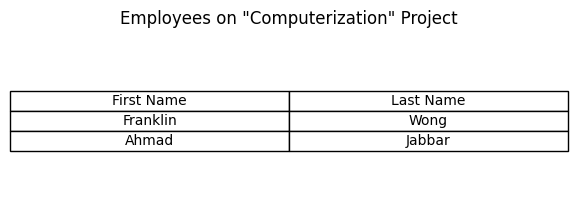

In [38]:
df1 = pd.DataFrame(results_1_1, columns=['First Name', 'Last Name'])

if not df1.empty:
    fig, ax = plt.subplots(figsize=(6, len(df1)*0.4 + 1))
    ax.axis('tight')
    ax.axis('off')

    # Create the table
    table = ax.table(cellText=df1.values,
                     colLabels=df1.columns,
                     cellLoc='center',
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    ax.set_title('Employees on "Computerization" Project', pad=20)

    plt.show()
else:
    print("No data for CONSULTA 01 to visualize.")
    conn.close()

In [8]:
"""Já a segunda query irá retornas nomes dos dependentes, vinculados a funcionários e que tem o sobrenome 'Smith'."""

"Já a segunda query irá retornas nomes dos dependentes, vinculados a funcionários e que tem o sobrenome 'Smith'."

In [41]:
c2 = conn.execute('''
SELECT D.Dependent_name
FROM DEPENDENT AS D
    INNER JOIN EMPLOYEE AS E 
        ON E.ssn = D.Essn AND E.Lname = 'Smith'
''')
print("Resultado CONSULTA 02")
results_1_2 = c2.fetchall()
print(results_1_2)
print("-------")
print('\n')

Resultado CONSULTA 02
[('Alice',), ('Joy',), ('Theodore',)]
-------




Resultado CONSULTA 02 (DataFrame):
  Dependent Name
0          Alice
1            Joy
2       Theodore
-------




/tmp/ipykernel_76124/2850144557.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Dependent Name', data=df2, palette='viridis',legend = False)


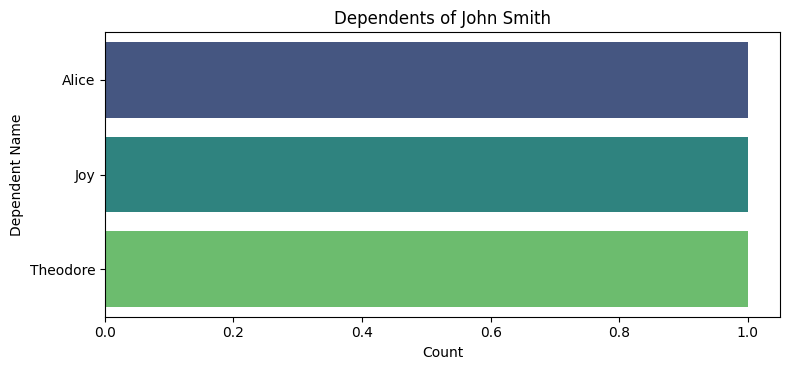

In [ ]:
df2 = pd.DataFrame(results_1_2, columns=['Dependent Name'])

print("Resultado CONSULTA 02 (DataFrame):")
print(df2)
print("-------")
print('\n')

if not df2.empty:
    plt.figure(figsize=(8, len(df2)*0.6 + 2))

    sns.countplot(y='Dependent Name', data=df2, palette='viridis', legend = False)

    plt.title('Dependents of John Smith')
    plt.xlabel('Count')
    plt.ylabel('Dependent Name')
    plt.tight_layout()
    plt.show()

In [10]:
"""A terceira query irá conter o nome de cada departamento juntamente com a média salarial dos funcionários que pertencem a esse departamento."""

'A terceira query irá conter o nome de cada departamento juntamente com a média salarial dos funcionários que pertencem a esse departamento.'

In [47]:
c3 = conn.execute('''
SELECT D.Dname, AVG(E.Salary)
FROM DEPARTMENT AS D
    INNER JOIN EMPLOYEE AS E 
        ON D.Dnumber = E.Dno
GROUP BY D.Dname
''')
print("Resultado CONSULTA 03 (Raw Data):")
result_1_3 = c3.fetchall()
print(result_1_3)
print("-------")
print('\n')

Resultado CONSULTA 03 (Raw Data):
[('Administration', 34000.0), ('Headquarters', 55000.0), ('Research', 31600.0)]
-------




Resultado CONSULTA 03 (DataFrame):
  Department Name  Average Salary
0  Administration         34000.0
1    Headquarters         55000.0
2        Research         31600.0
-------




/tmp/ipykernel_76124/3851241185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department Name', y='Average Salary', data=df3, palette='coolwarm')


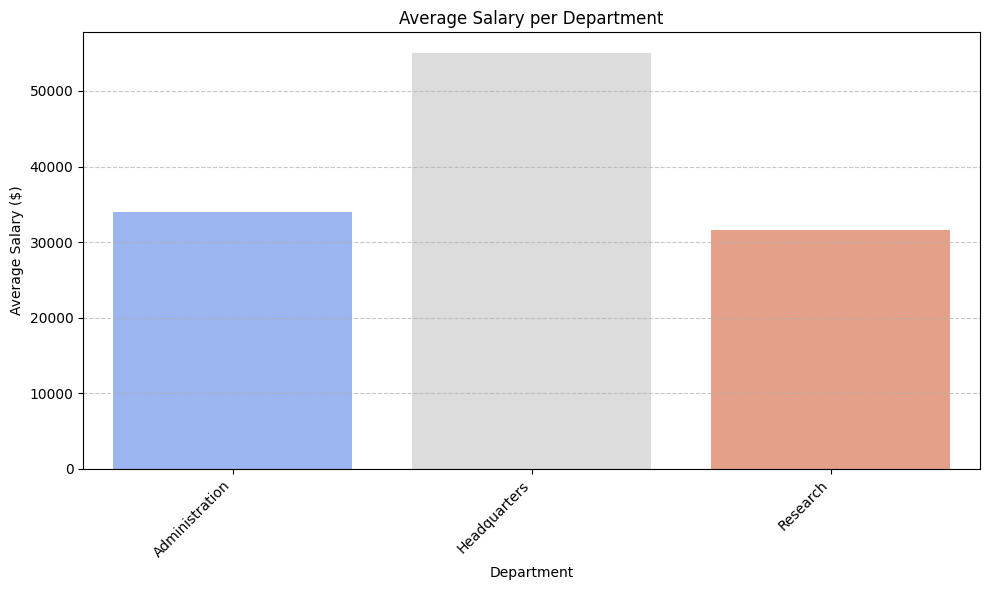

In [48]:
df3 = pd.DataFrame(result_1_3, columns=['Department Name', 'Average Salary'])

print("Resultado CONSULTA 03 (DataFrame):")
print(df3)
print("-------")
print('\n')

if not df3.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Department Name', y='Average Salary', data=df3, palette='coolwarm')
    plt.title('Average Salary per Department')
    plt.xlabel('Department')
    plt.ylabel('Average Salary ($)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data for CONSULTA 03 to visualize.")

In [12]:
""" A consuta 4 retornará o número de cada projeto e a contagem de funcionários que trabalham nesses projetos."""

' A consuta 4 retornará o número de cada projeto e a contagem de funcionários que trabalham nesses projetos.'

In [49]:
c4 = conn.execute('''
SELECT P.Pnumber, COUNT(WO.Essn)
FROM PROJECT AS P
    INNER JOIN WORKS_ON AS WO
        ON P.Pnumber = WO.Pno
GROUP BY P.Pnumber
''')
print("Resultado CONSULTA 04 (Raw Data):")
results_1_4 = c4.fetchall()

print(results_1_4)
print("-------")
print('\n')


Resultado CONSULTA 04 (Raw Data):
[(1, 2), (2, 3), (3, 2), (10, 2), (20, 2), (30, 3)]
-------




Resultado CONSULTA 04 (DataFrame):
   Project Name  Number of Employees
0             1                    2
1             2                    3
2             3                    2
3            10                    2
4            20                    2
5            30                    3
-------




/tmp/ipykernel_76124/2599168862.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Project Name', y='Number of Employees', data=df4, palette='rocket')


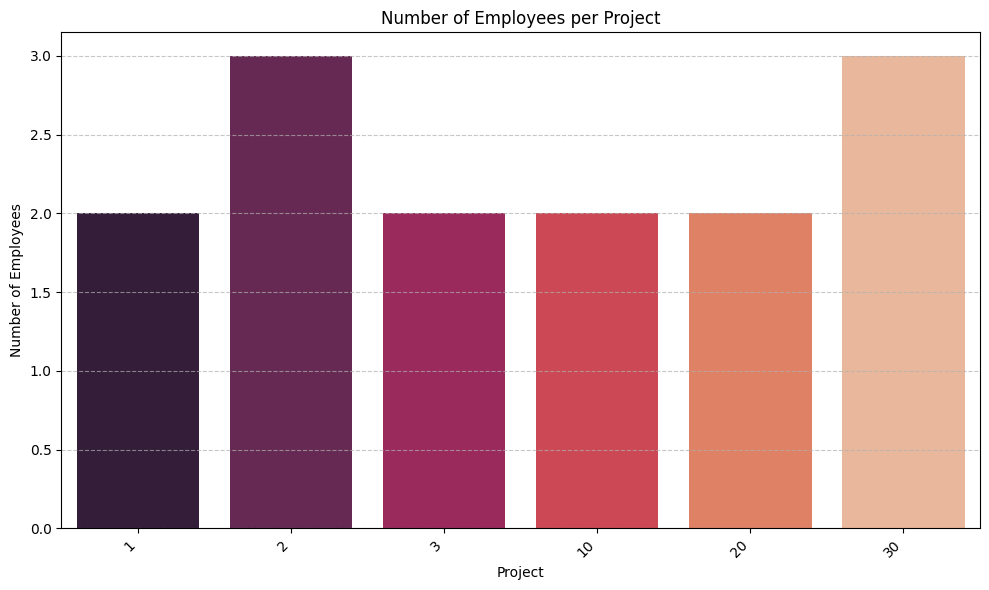

In [ ]:
df4 = pd.DataFrame(results_1_4, columns=['Project Name', 'Number of Employees'])

print("Resultado CONSULTA 04 (DataFrame):")
print(df4)
print("-------")
print('\n')

if not df4.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Project Name', y='Number of Employees', data=df4, palette='rocket')
    plt.title('Number of Employees per Project')
    plt.xlabel('Project')
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data for CONSULTA 04 to visualize.")

In [14]:
""" A consulta retorna os nomes e sobrenomes dos funcionários que estão alocados em mais de um projeto."""

' A consulta retorna os nomes e sobrenomes dos funcionários que estão alocados em mais de um projeto.'

In [53]:
c5 = conn.execute('''
SELECT E.Fname, E.Lname
FROM EMPLOYEE AS E
    INNER JOIN WORKS_ON AS WO
        ON E.ssn = WO.Essn
GROUP BY E.ssn
HAVING COUNT(WO.Pno) > 1
''')
print("Resultado CONSULTA 05 (Raw Data):")
results_1_5 = c5.fetchall()
print(results_1_5)
print("-------")
print('\n')


Resultado CONSULTA 05 (Raw Data):
[('John', 'Smith'), ('Franklin', 'Wong'), ('Joyce', 'English'), ('Jennifer', 'Wallace'), ('Ahmad', 'Jabbar')]
-------




## QUESTÃO 2

In [16]:
# Último exemplo slide
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(*)
FROM DEPARTMENT AS D, EMPLOYEE AS E
WHERE D.Dnumber = E.Dno AND E.SALARY > 40000
GROUP BY D.Dnumber
''')
print("Resultado QUESTÃO 02")
print(q2_c1.fetchall())
print("-------")
print('\n')

Resultado QUESTÃO 02
[(1, 1), (4, 1)]
-------




Vemos que essa consulta retorna o número dos departamentos que possuem funcionários que recebem mais de 40000 de salário.

In [22]:
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(*)
FROM DEPARTMENT AS D, EMPLOYEE AS E
WHERE D.Dnumber = E.Dno AND E.SALARY > 40000 AND D.Dnumber IN (
                     SELECT E.Dno FROM EMPLOYEE AS E GROUP BY E.Dno HAVING COUNT(*) > 5)
GROUP BY D.Dnumber
''')
print("Resultado QUESTÃO 02")
results_q2_c1 = q2_c1.fetchall()
print(q2_c1.fetchall())
print("-------")
print('\n')

Resultado QUESTÃO 02
[]
-------




In [ ]:
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(*)
FROM DEPARTMENT AS D, EMPLOYEE AS E
WHERE D.Dnumber = E.Dno AND E.SALARY > 40000 AND D.Dnumber IN (
                     SELECT E.Dno FROM EMPLOYEE AS E GROUP BY E.Dno HAVING COUNT(*) > 5)
GROUP BY D.Dnumber
''')
print("Resultado QUESTÃO 02")
print(q2_c1.fetchall())
print("-------")
print('\n')

## QUESTÃO 3

## QUESTÃO 4

In [14]:
conn.close()